In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Superstore.csv to Superstore.csv


In [ ]:
import os

print(os.listdir())

['.config', 'Superstore.csv', 'sample_data']


In [ ]:
df = pd.read_csv("Superstore.csv", encoding='latin1')

In [ ]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (9994, 21)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9994.0,NaN,NaN,NaN,4997.5,2885.163629,1.0,2499.25,4997.5,7495.75,9994.0
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,1237,09-05-2016,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9994,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Series([], dtype: int64)


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (9994, 21)


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
print(df[['Order Date', 'Ship Date']].head())

  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-11-08 2016-11-11
2 2016-06-12        NaT
3 2015-10-11        NaT
4 2015-10-11        NaT


In [ ]:
df = df.dropna()

print("Shape after handling missing values:", df.shape)

Shape after handling missing values: (2739, 21)


In [ ]:
df['Year'] = df['Order Date'].dt.year

In [ ]:
df['Month'] = df['Order Date'].dt.month

In [ ]:
df['Month Name'] = df['Order Date'].dt.month_name()

In [ ]:
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)

In [ ]:
df[['Order Date', 'Year', 'Month', 'Month Name', 'Year-Month']].head()

,Order Date,Year,Month,Month Name,Year-Month
0,2016-11-08,2016,11,November,2016-11
1,2016-11-08,2016,11,November,2016-11
13,2016-12-05,2016,12,December,2016-12
35,2016-12-08,2016,12,December,2016-12
36,2016-12-08,2016,12,December,2016-12


In [ ]:
total_sales = df['Sales'].sum()

print("Total Sales: $", round(total_sales, 2))

Total Sales: $ 632630.68


In [ ]:
total_profit = df['Profit'].sum()

print("Total Profit: $", round(total_profit, 2))

Total Profit: $ 85801.14


In [ ]:
total_orders = df['Order ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 1358


In [ ]:
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 669


In [ ]:
average_order_value = total_sales / total_orders

print("Average Order Value: $", round(average_order_value, 2))

Average Order Value: $ 465.85


In [ ]:
profit_margin = (total_profit / total_sales) * 100

print("Profit Margin:", round(profit_margin, 2), "%")

Profit Margin: 13.56 %


In [ ]:
kpi = pd.DataFrame({
    'KPI': [
        'Total Sales',
        'Total Profit',
        'Total Orders',
        'Total Customers',
        'Average Order Value',
        'Profit Margin'
    ],
    'Value': [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        average_order_value,
        profit_margin
    ]
})

display(kpi)

,KPI,Value
0,Total Sales,632630.683900
1,Total Profit,85801.137900
2,Total Orders,1358.000000
3,Total Customers,669.000000
4,Average Order Value,465.854701
5,Profit Margin,13.562595


In [ ]:
monthly_sales = df.groupby('Year-Month')['Sales'].sum().reset_index()

display(monthly_sales.head())

,Year-Month,Sales
0,2014-01,4818.302
1,2014-02,1437.434
2,2014-03,6388.503
3,2014-04,12142.280
4,2014-05,4331.647


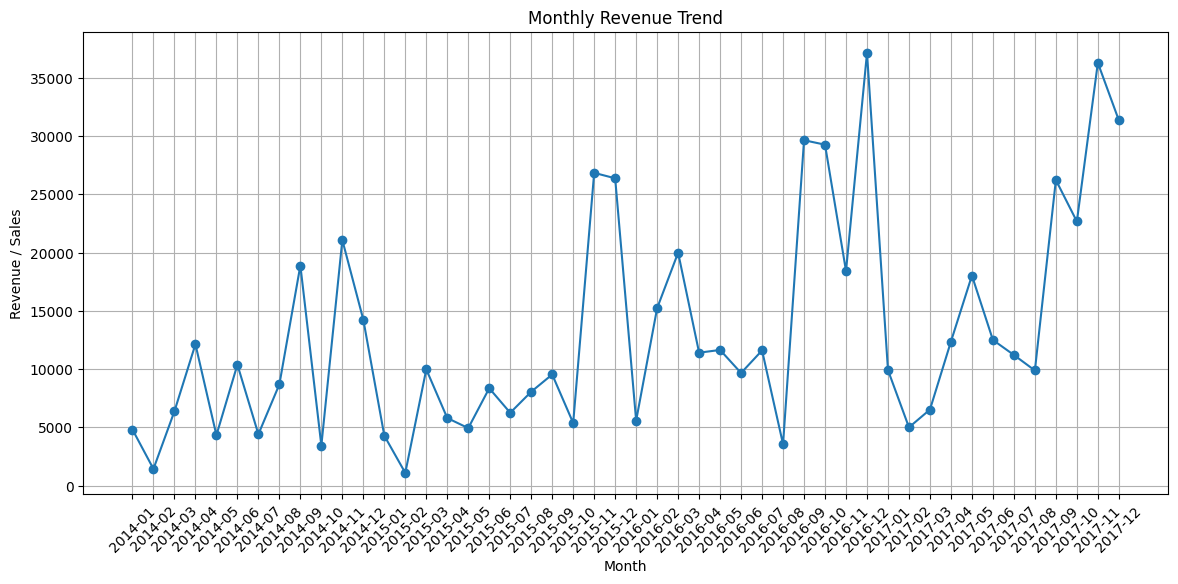

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['Year-Month'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue / Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

display(yearly_sales)

,Year,Sales
0,2014,110303.9300
1,2015,116978.3842
2,2016,203260.2334
3,2017,202088.1363


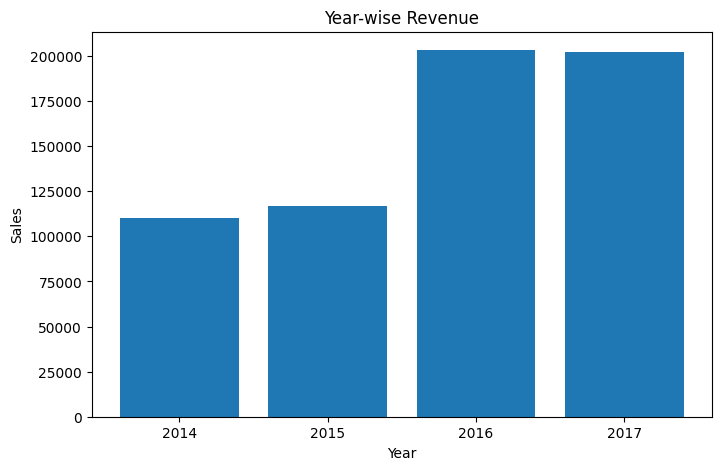

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales['Year'].astype(str),
    yearly_sales['Sales']
)

plt.title('Year-wise Revenue')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.show()

In [ ]:
yearly_profit = df.groupby('Year')['Profit'].sum().reset_index()

display(yearly_profit)

,Year,Profit
0,2014,13820.1589
1,2015,12555.8569
2,2016,36504.5339
3,2017,22920.5882


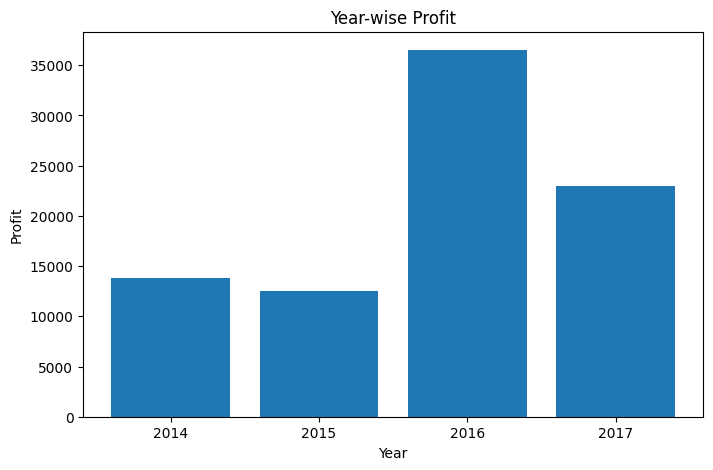

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_profit['Year'].astype(str),
    yearly_profit['Profit']
)

plt.title('Year-wise Profit')
plt.xlabel('Year')
plt.ylabel('Profit')

plt.show()

In [ ]:
top_profit_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_profit_products)

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,8399.9760
Hewlett Packard LaserJet 3310 Copier,3167.9472
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",2799.9840
Ativa V4110MDD Micro-Cut Shredder,2400.9657
Honeywell Enviracaire Portable HEPA Air Cleaner for 17' x 22' Room,2281.9335
Canon PC1060 Personal Laser Copier,2267.9676
Zebra ZM400 Thermal Label Printer,2229.0240
Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier,1995.9900
Canon Imageclass D680 Copier / Fax,1854.9735


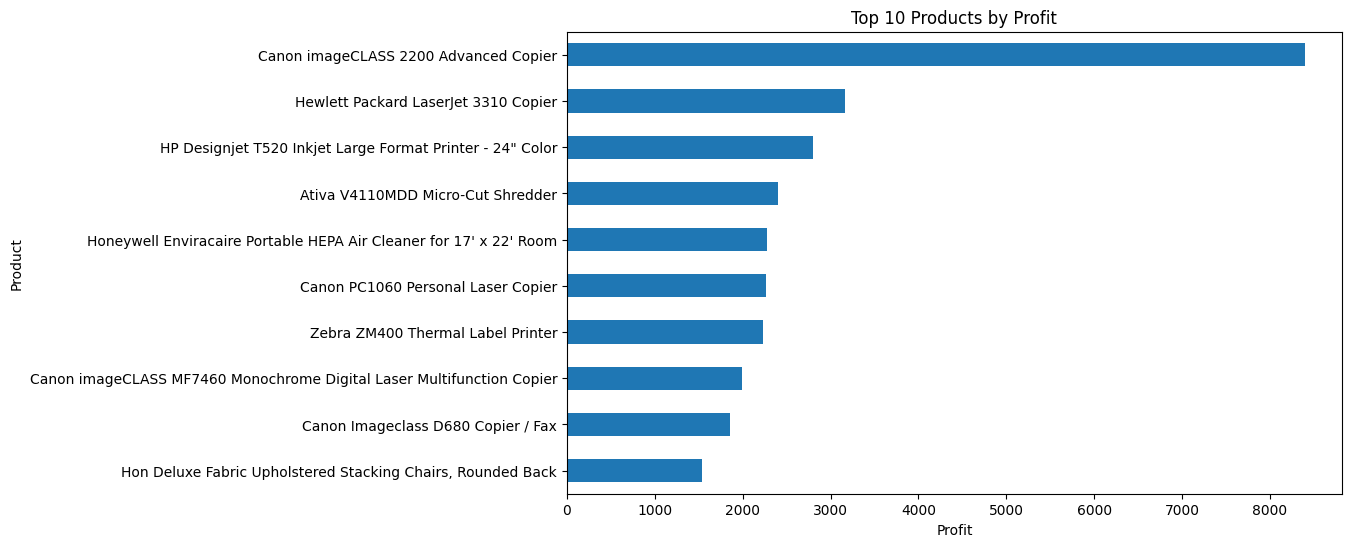

In [ ]:
plt.figure(figsize=(10,6))

top_profit_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.show()

In [ ]:
loss_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

display(loss_products)

,Profit
Product Name,
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
GBC Ibimaster 500 Manual ProClick Binding System,-1369.7640
Hoover Upright Vacuum With Dirt Cup,-1181.2824
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-1101.9600
Cisco 9971 IP Video Phone Charcoal,-950.4000
Zebra GK420t Direct Thermal/Thermal Transfer Printer,-938.2800
3.6 Cubic Foot Counter Height Office Refrigerator,-813.1512
High Speed Automatic Electric Letter Opener,-786.0144
Lexmark MX611dhe Monochrome Laser Printer,-679.9960


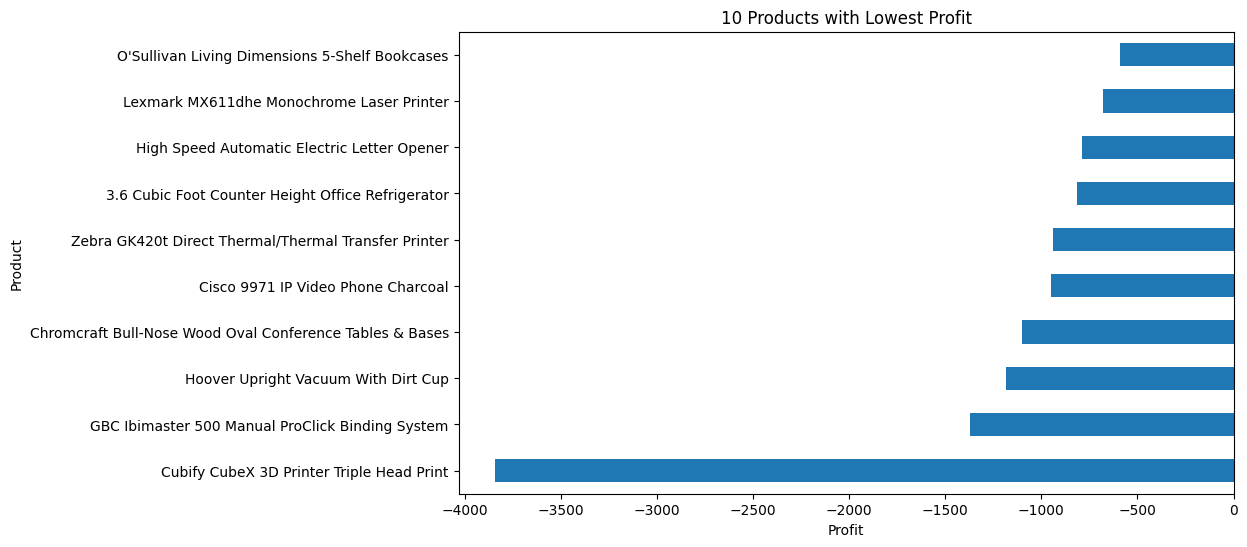

In [ ]:
plt.figure(figsize=(10,6))

loss_products.plot(kind='barh')

plt.title('10 Products with Lowest Profit')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.show()

In [ ]:
category_analysis = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

category_analysis.columns = [
    'Category',
    'Sales',
    'Profit',
    'Orders'
]

display(category_analysis)

,Category,Sales,Profit,Orders
0,Furniture,200920.7049,8025.5042,475
1,Office Supplies,175319.8440,27021.7787,1015
2,Technology,256390.1350,50753.8550,432


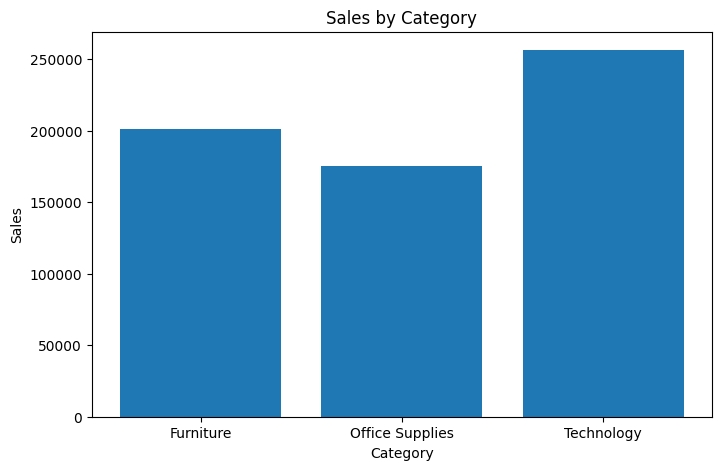

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis['Category'],
    category_analysis['Sales']
)

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

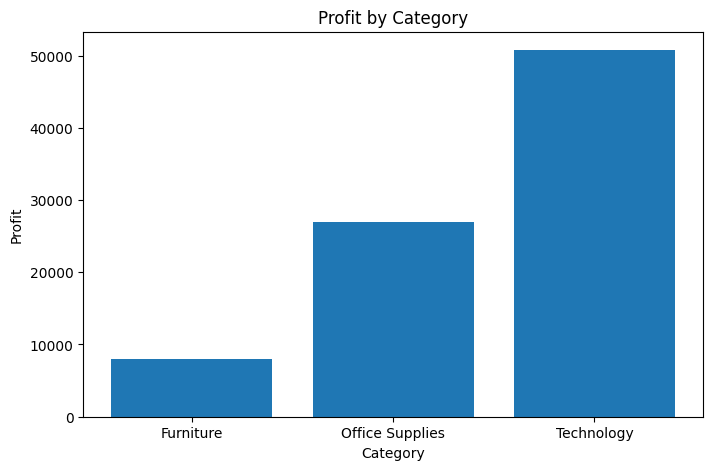

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis['Category'],
    category_analysis['Profit']
)

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.show()

In [ ]:
subcategory_analysis = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

display(
    subcategory_analysis.sort_values(
        'Sales',
        ascending=False
    )
)

,Sub-Category,Sales,Profit
5,Chairs,90947.3860,9980.2774
13,Phones,83805.5520,12302.2866
11,Machines,74140.4570,5858.9998
14,Storage,54722.1320,6487.9576
16,Tables,53592.5615,-3456.9023
6,Copiers,49409.3500,19415.7755
0,Accessories,49034.7760,13176.7931
3,Binders,42929.3400,4667.5490
4,Bookcases,31091.8254,-878.1061
1,Appliances,27771.9620,2368.2777


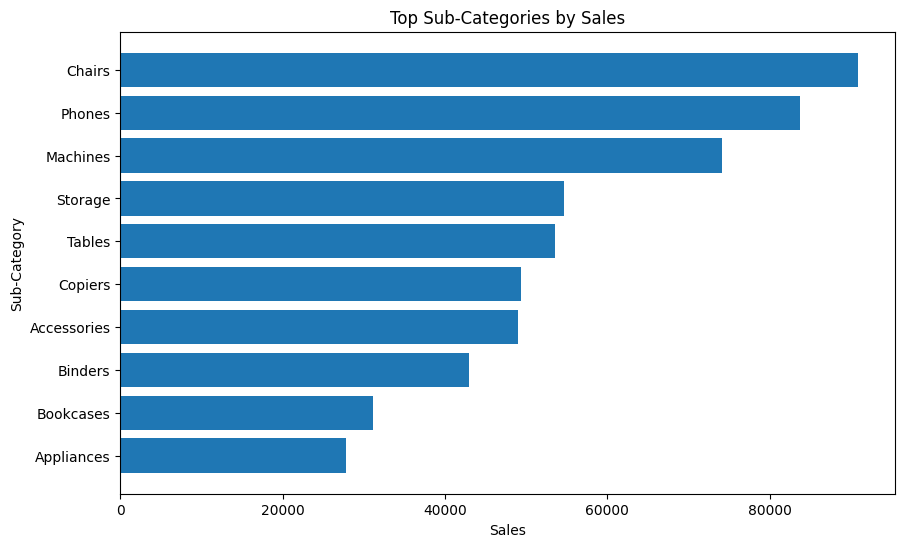

In [ ]:
top_subcategories = (
    subcategory_analysis
    .sort_values('Sales', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_subcategories['Sub-Category'][::-1],
    top_subcategories['Sales'][::-1]
)

plt.title('Top Sub-Categories by Sales')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')

plt.show()

In [ ]:
region_analysis = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

region_analysis.columns = [
    'Region',
    'Sales',
    'Profit',
    'Orders'
]

display(region_analysis)

,Region,Sales,Profit,Orders
0,Central,152624.3104,13350.4239,330
1,East,178432.9930,32963.6171,373
2,South,115010.1675,10399.6015,230
3,West,186563.2130,29087.4954,425


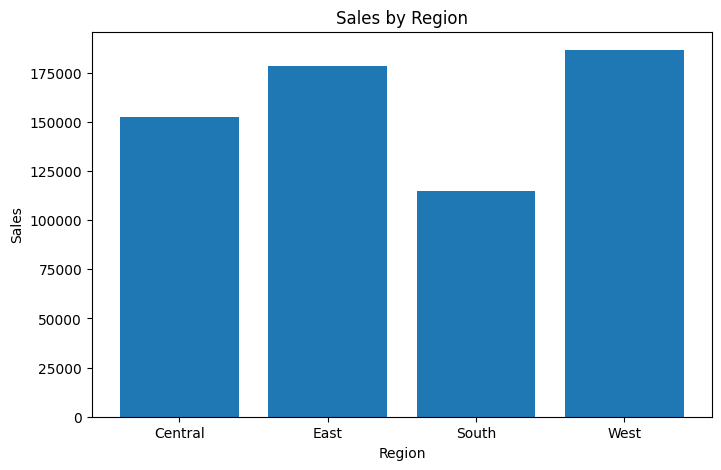

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis['Region'],
    region_analysis['Sales']
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

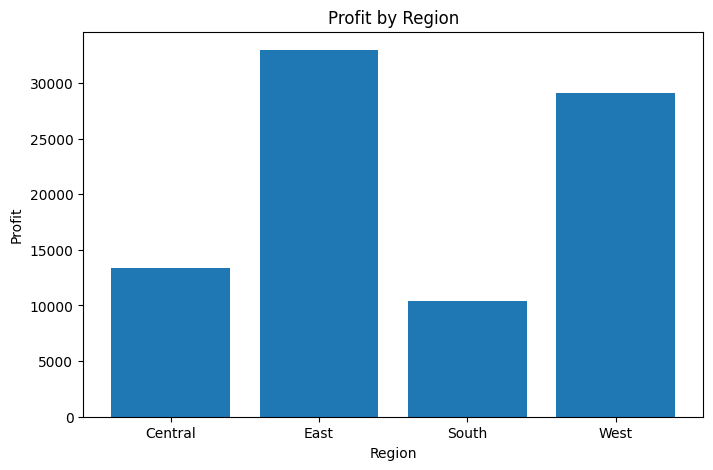

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis['Region'],
    region_analysis['Profit']
)

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')

plt.show()

In [ ]:
state_analysis = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

top_states = state_analysis.sort_values(
    'Sales',
    ascending=False
).head(10)

display(top_states)

,State,Sales,Profit
3,California,122989.2540,22394.7303
29,New York,91708.2440,24163.1572
38,Texas,59888.8174,-10516.2798
42,Washington,33278.6480,6201.4399
12,Indiana,28937.8500,12067.6973
41,Virginia,26156.8200,6271.9215
30,North Carolina,25788.6290,-3416.7672
34,Pennsylvania,23283.3550,-3271.1281
8,Florida,21656.1045,-684.2757
20,Michigan,18245.2380,5259.8477


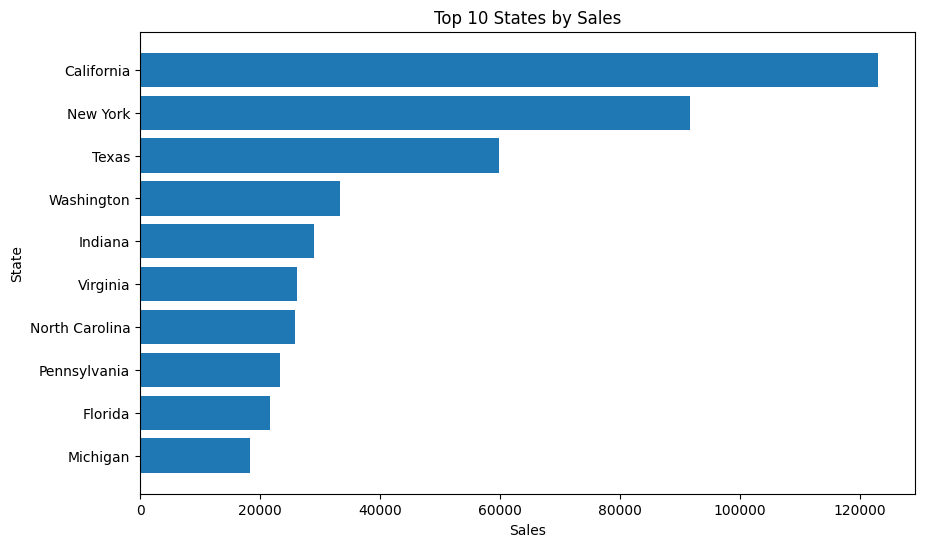

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top_states['State'][::-1],
    top_states['Sales'][::-1]
)

plt.title('Top 10 States by Sales')
plt.xlabel('Sales')
plt.ylabel('State')

plt.show()

In [ ]:
segment_analysis = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

segment_analysis.columns = [
    'Segment',
    'Sales',
    'Profit',
    'Orders'
]

display(segment_analysis)

,Segment,Sales,Profit,Orders
0,Consumer,295429.7350,34270.9848,686
1,Corporate,205852.2324,26573.8221,422
2,Home Office,131348.7165,24956.3310,250


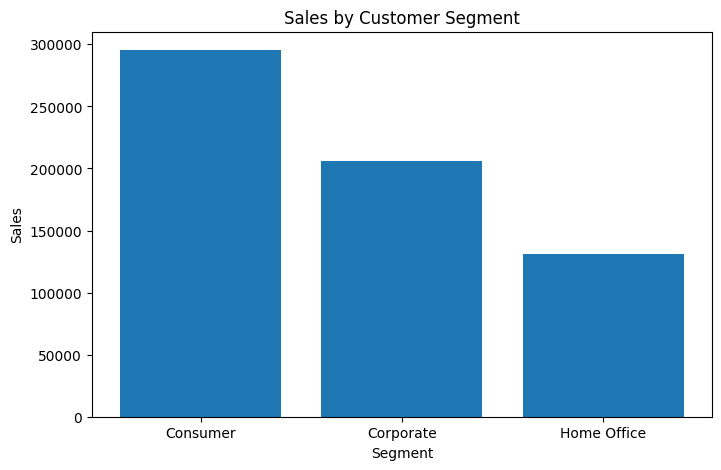

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_analysis['Segment'],
    segment_analysis['Sales']
)

plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Sales')

plt.show()

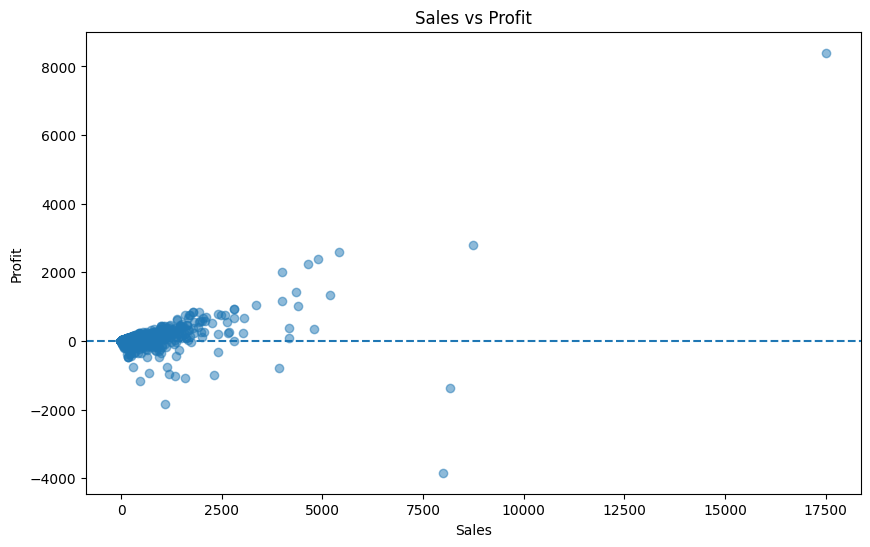

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Sales'],
    df['Profit'],
    alpha=0.5
)

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.axhline(0, linestyle='--')

plt.show()

In [ ]:
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()

display(discount_profit)

,Discount,Profit
0,0.00,74.273388
1,0.10,95.201697
2,0.15,34.205015
3,0.20,22.859074
4,0.30,-39.331821
5,0.32,-198.156229
6,0.40,-115.042043
7,0.45,-269.480200
8,0.50,-372.243794
9,0.60,-56.790438


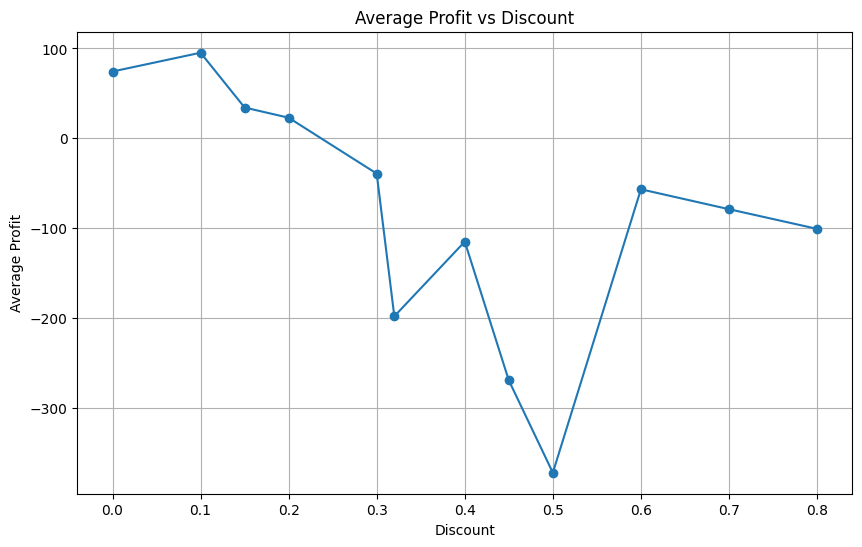

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    discount_profit['Discount'],
    discount_profit['Profit'],
    marker='o'
)

plt.title('Average Profit vs Discount')
plt.xlabel('Discount')
plt.ylabel('Average Profit')

plt.grid(True)

plt.show()

In [ ]:
business_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

business_summary['Profit Margin %'] = (
    business_summary['Total_Profit'] /
    business_summary['Total_Sales']
) * 100

business_summary = business_summary.sort_values(
    'Total_Sales',
    ascending=False
)

display(business_summary)

,Category,Total_Sales,Total_Profit,Orders,Profit Margin %
2,Technology,256390.1350,50753.8550,432,19.795557
0,Furniture,200920.7049,8025.5042,475,3.994364
1,Office Supplies,175319.8440,27021.7787,1015,15.412847


In [ ]:
highest_sales_category = category_analysis.loc[
    category_analysis['Sales'].idxmax()
]

highest_profit_category = category_analysis.loc[
    category_analysis['Profit'].idxmax()
]

highest_sales_region = region_analysis.loc[
    region_analysis['Sales'].idxmax()
]

highest_profit_region = region_analysis.loc[
    region_analysis['Profit'].idxmax()
]

best_product = top_products.index[0]

print("BUSINESS INSIGHTS")
print("=" * 50)

print(
    f"1. Highest-sales category: "
    f"{highest_sales_category['Category']}"
)

print(
    f"2. Highest-profit category: "
    f"{highest_profit_category['Category']}"
)

print(
    f"3. Highest-sales region: "
    f"{highest_sales_region['Region']}"
)

print(
    f"4. Highest-profit region: "
    f"{highest_profit_region['Region']}"
)

print(
    f"5. Top-selling product: "
    f"{best_product}"
)

print(
    f"6. Overall profit margin: "
    f"{profit_margin:.2f}%"
)

BUSINESS INSIGHTS
1. Highest-sales category: Technology
2. Highest-profit category: Technology
3. Highest-sales region: West
4. Highest-profit region: East
5. Top-selling product: Canon imageCLASS 2200 Advanced Copier
6. Overall profit margin: 13.56%


In [ ]:
print("SUPERSTORE SALES ANALYSIS")
print("=" * 60)

print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Average Order     : ${average_order_value:,.2f}")
print(f"Profit Margin     : {profit_margin:.2f}%")

print("\nKEY BUSINESS AREAS")
print("-" * 60)

print(
    f"Top Sales Category : "
    f"{highest_sales_category['Category']}"
)

print(
    f"Top Profit Category: "
    f"{highest_profit_category['Category']}"
)

print(
    f"Top Sales Region   : "
    f"{highest_sales_region['Region']}"
)

print(
    f"Top Profit Region  : "
    f"{highest_profit_region['Region']}"
)

print(
    f"Top Product        : "
    f"{best_product}"
)

SUPERSTORE SALES ANALYSIS
Total Sales       : $632,630.68
Total Profit      : $85,801.14
Total Orders      : 1,358
Total Customers   : 669
Average Order     : $465.85
Profit Margin     : 13.56%

KEY BUSINESS AREAS
------------------------------------------------------------
Top Sales Category : Technology
Top Profit Category: Technology
Top Sales Region   : West
Top Profit Region  : East
Top Product        : Canon imageCLASS 2200 Advanced Copier


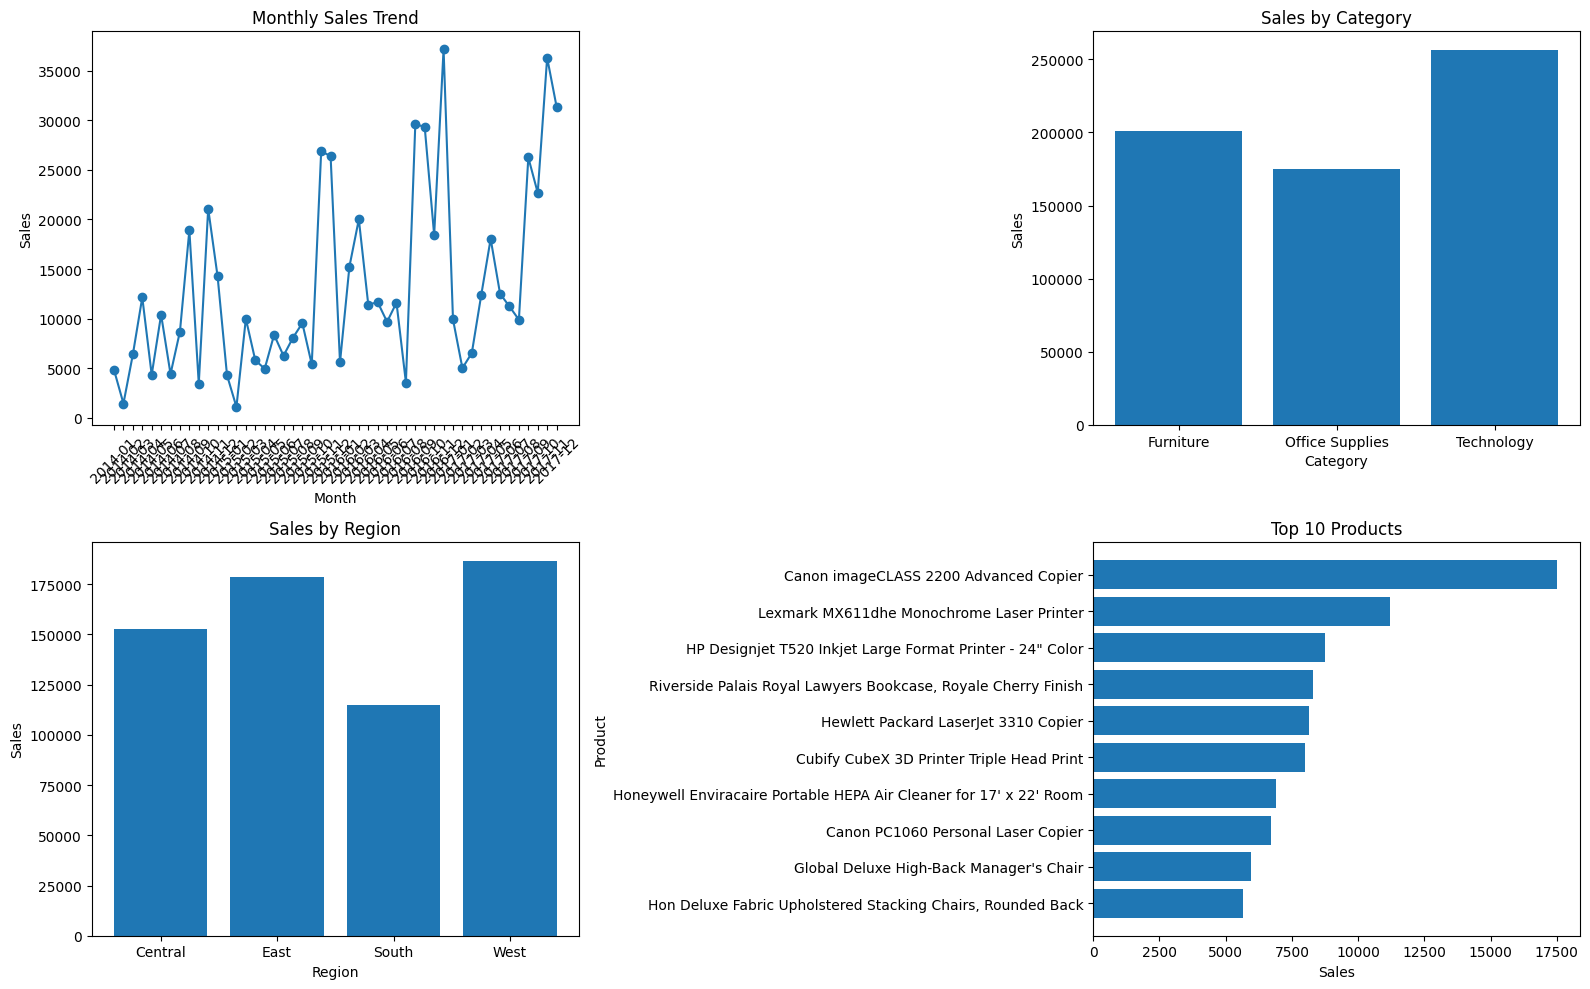

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# 1. Monthly sales
axes[0,0].plot(
    monthly_sales['Year-Month'],
    monthly_sales['Sales'],
    marker='o'
)

axes[0,0].set_title('Monthly Sales Trend')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Sales')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Category sales
axes[0,1].bar(
    category_analysis['Category'],
    category_analysis['Sales']
)

axes[0,1].set_title('Sales by Category')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Sales')

# 3. Region sales
axes[1,0].bar(
    region_analysis['Region'],
    region_analysis['Sales']
)

axes[1,0].set_title('Sales by Region')
axes[1,0].set_xlabel('Region')
axes[1,0].set_ylabel('Sales')

# 4. Top products
axes[1,1].barh(
    top_products.index[::-1],
    top_products.values[::-1]
)

axes[1,1].set_title('Top 10 Products')
axes[1,1].set_xlabel('Sales')
axes[1,1].set_ylabel('Product')

plt.tight_layout()
plt.show()

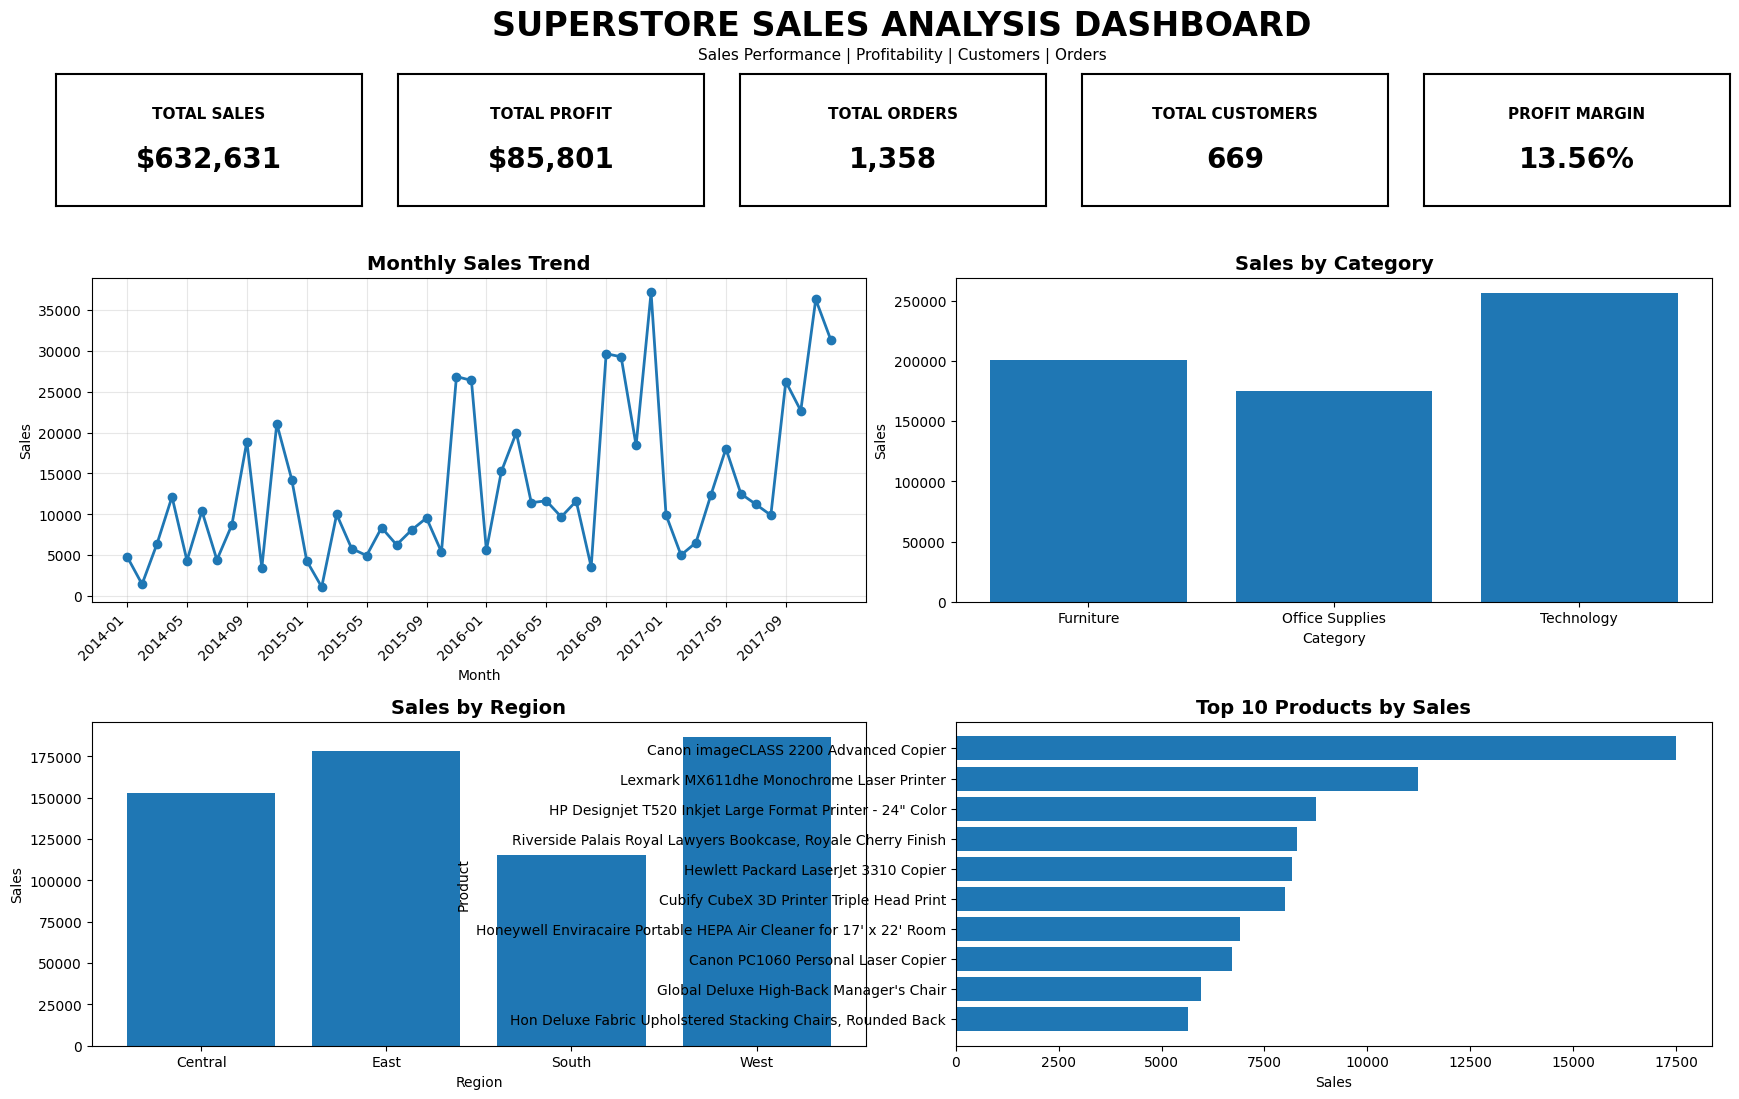

In [ ]:
# ============================================================
# PROFESSIONAL SUPERSTORE SALES DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Create dashboard
fig = plt.figure(figsize=(18, 12))

# ------------------------------------------------------------
# KPI CARDS
# ------------------------------------------------------------

# KPI positions: [left, bottom, width, height]
kpi_positions = [
    [0.03, 0.82, 0.17, 0.11],   # Total Sales
    [0.22, 0.82, 0.17, 0.11],   # Total Profit
    [0.41, 0.82, 0.17, 0.11],   # Total Orders
    [0.60, 0.82, 0.17, 0.11],   # Total Customers
    [0.79, 0.82, 0.17, 0.11]    # Profit Margin
]

kpi_data = [
    ("TOTAL SALES", f"${total_sales:,.0f}"),
    ("TOTAL PROFIT", f"${total_profit:,.0f}"),
    ("TOTAL ORDERS", f"{total_orders:,}"),
    ("TOTAL CUSTOMERS", f"{total_customers:,}"),
    ("PROFIT MARGIN", f"{profit_margin:.2f}%")
]

for position, (title, value) in zip(kpi_positions, kpi_data):

    ax = fig.add_axes(position)

    # Remove axes
    ax.set_xticks([])
    ax.set_yticks([])

    # Card border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)

    # KPI title
    ax.text(
        0.5, 0.70,
        title,
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

    # KPI value
    ax.text(
        0.5, 0.35,
        value,
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold'
    )


# ------------------------------------------------------------
# DASHBOARD TITLE
# ------------------------------------------------------------

fig.text(
    0.5, 0.97,
    'SUPERSTORE SALES ANALYSIS DASHBOARD',
    ha='center',
    va='center',
    fontsize=24,
    fontweight='bold'
)

fig.text(
    0.5, 0.945,
    'Sales Performance | Profitability | Customers | Orders',
    ha='center',
    va='center',
    fontsize=11
)


# ------------------------------------------------------------
# 1. MONTHLY SALES TREND
# ------------------------------------------------------------

ax1 = fig.add_axes([0.05, 0.49, 0.43, 0.27])

ax1.plot(
    monthly_sales['Year-Month'],
    monthly_sales['Sales'],
    marker='o',
    linewidth=2
)

ax1.set_title(
    'Monthly Sales Trend',
    fontsize=14,
    fontweight='bold'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Sales')

# Show fewer x-axis labels
step = max(1, len(monthly_sales) // 12)

ax1.set_xticks(
    range(0, len(monthly_sales), step)
)

ax1.set_xticklabels(
    monthly_sales['Year-Month'].iloc[::step],
    rotation=45,
    ha='right'
)

ax1.grid(alpha=0.3)


# ------------------------------------------------------------
# 2. SALES BY CATEGORY
# ------------------------------------------------------------

ax2 = fig.add_axes([0.53, 0.49, 0.42, 0.27])

ax2.bar(
    category_analysis['Category'],
    category_analysis['Sales']
)

ax2.set_title(
    'Sales by Category',
    fontsize=14,
    fontweight='bold'
)

ax2.set_xlabel('Category')
ax2.set_ylabel('Sales')


# ------------------------------------------------------------
# 3. SALES BY REGION
# ------------------------------------------------------------

ax3 = fig.add_axes([0.05, 0.12, 0.43, 0.27])

ax3.bar(
    region_analysis['Region'],
    region_analysis['Sales']
)

ax3.set_title(
    'Sales by Region',
    fontsize=14,
    fontweight='bold'
)

ax3.set_xlabel('Region')
ax3.set_ylabel('Sales')


# ------------------------------------------------------------
# 4. TOP 10 PRODUCTS
# ------------------------------------------------------------

ax4 = fig.add_axes([0.53, 0.12, 0.42, 0.27])

top_product_data = top_products.sort_values()

ax4.barh(
    top_product_data.index,
    top_product_data.values
)

ax4.set_title(
    'Top 10 Products by Sales',
    fontsize=14,
    fontweight='bold'
)

ax4.set_xlabel('Sales')
ax4.set_ylabel('Product')


# ------------------------------------------------------------
# DISPLAY DASHBOARD
# ------------------------------------------------------------

plt.show()

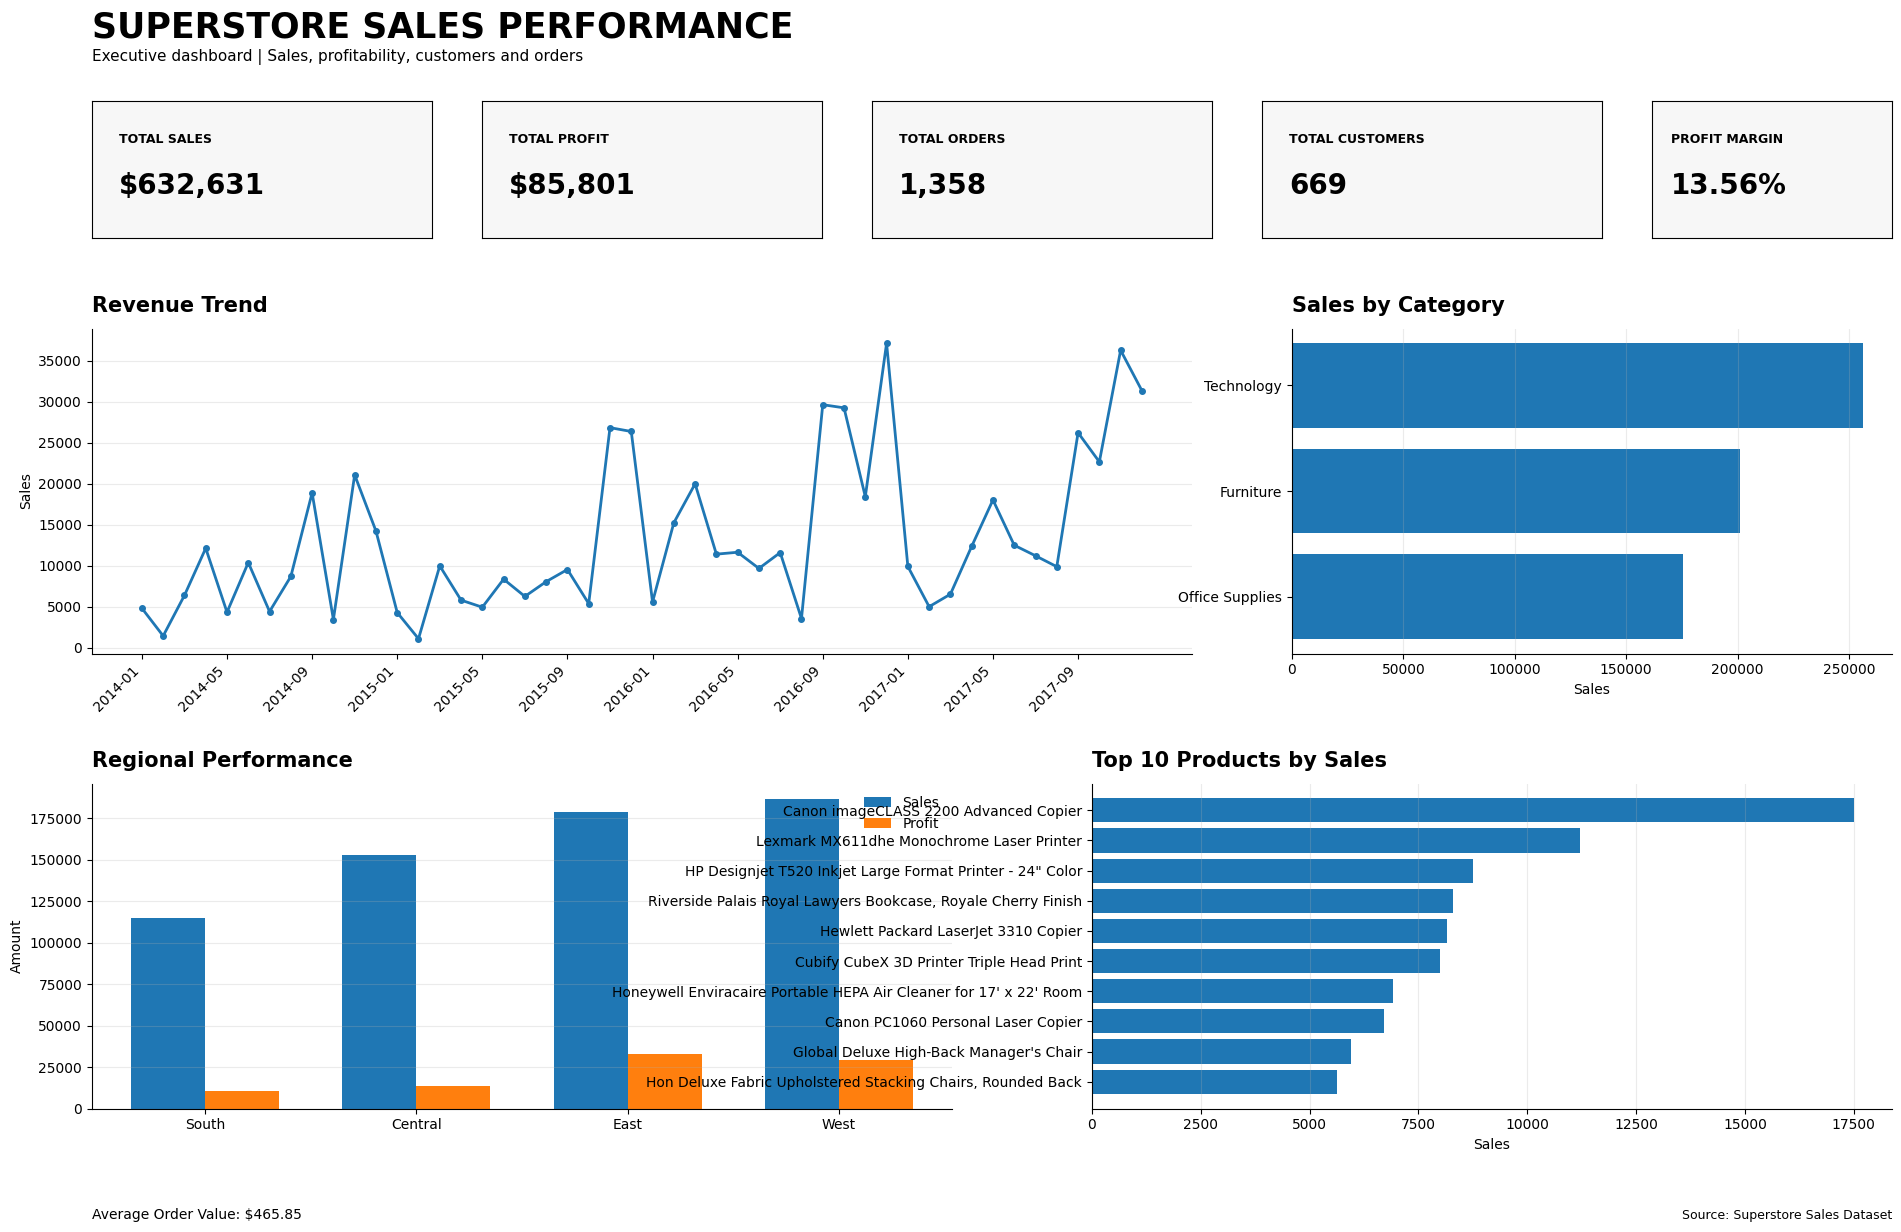

In [ ]:
# ============================================================
# PROFESSIONAL SUPERSTORE SALES DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

# Monthly sales
monthly_sales = (
    df.groupby('Year-Month')['Sales']
    .sum()
    .reset_index()
)

# Category analysis
category_dashboard = (
    df.groupby('Category')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
    .reset_index()
)

# Region analysis
region_dashboard = (
    df.groupby('Region')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
    .reset_index()
)

# Top 10 products
top_products_dashboard = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

# ------------------------------------------------------------
# 2. KPI VALUES
# ------------------------------------------------------------

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

profit_margin = (
    total_profit / total_sales
) * 100

average_order_value = (
    total_sales / total_orders
)

# ------------------------------------------------------------
# 3. CREATE FIGURE
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(20, 13),
    facecolor='white'
)

# ------------------------------------------------------------
# 4. DASHBOARD TITLE
# ------------------------------------------------------------

fig.text(
    0.05, 0.965,
    'SUPERSTORE SALES PERFORMANCE',
    fontsize=25,
    fontweight='bold',
    va='top'
)

fig.text(
    0.05, 0.935,
    'Executive dashboard | Sales, profitability, customers and orders',
    fontsize=11,
    va='top'
)

# ------------------------------------------------------------
# 5. KPI CARDS
# ------------------------------------------------------------

kpi_values = [
    f'${total_sales:,.0f}',
    f'${total_profit:,.0f}',
    f'{total_orders:,}',
    f'{total_customers:,}',
    f'{profit_margin:.2f}%'
]

kpi_titles = [
    'TOTAL SALES',
    'TOTAL PROFIT',
    'TOTAL ORDERS',
    'TOTAL CUSTOMERS',
    'PROFIT MARGIN'
]

kpi_positions = [
    [0.05, 0.79, 0.17, 0.105],
    [0.245, 0.79, 0.17, 0.105],
    [0.44, 0.79, 0.17, 0.105],
    [0.635, 0.79, 0.17, 0.105],
    [0.83, 0.79, 0.12, 0.105]
]

for position, title, value in zip(
    kpi_positions,
    kpi_titles,
    kpi_values
):

    ax = fig.add_axes(position)

    ax.set_facecolor('#F7F7F7')

    ax.set_xticks([])
    ax.set_yticks([])

    # Clean card border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    # KPI title
    ax.text(
        0.08, 0.72,
        title,
        fontsize=9,
        fontweight='bold',
        va='center'
    )

    # KPI value
    ax.text(
        0.08, 0.38,
        value,
        fontsize=20,
        fontweight='bold',
        va='center'
    )


# ------------------------------------------------------------
# 6. MONTHLY SALES TREND
# ------------------------------------------------------------

ax1 = fig.add_axes(
    [0.05, 0.47, 0.55, 0.25]
)

ax1.plot(
    range(len(monthly_sales)),
    monthly_sales['Sales'],
    marker='o',
    markersize=4,
    linewidth=2
)

ax1.set_title(
    'Revenue Trend',
    loc='left',
    fontsize=15,
    fontweight='bold',
    pad=12
)

ax1.set_ylabel('Sales', fontsize=10)

# X-axis labels
step = max(1, len(monthly_sales) // 10)

ax1.set_xticks(
    range(0, len(monthly_sales), step)
)

ax1.set_xticklabels(
    monthly_sales['Year-Month'].iloc[::step],
    rotation=45,
    ha='right'
)

# Remove unnecessary borders
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.grid(
    axis='y',
    alpha=0.25
)


# ------------------------------------------------------------
# 7. SALES BY CATEGORY
# ------------------------------------------------------------

ax2 = fig.add_axes(
    [0.65, 0.47, 0.30, 0.25]
)

category_sorted = category_dashboard.sort_values(
    'Sales'
)

ax2.barh(
    category_sorted['Category'],
    category_sorted['Sales']
)

ax2.set_title(
    'Sales by Category',
    loc='left',
    fontsize=15,
    fontweight='bold',
    pad=12
)

ax2.set_xlabel('Sales', fontsize=10)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.grid(
    axis='x',
    alpha=0.25
)


# ------------------------------------------------------------
# 8. SALES & PROFIT BY REGION
# ------------------------------------------------------------

ax3 = fig.add_axes(
    [0.05, 0.12, 0.43, 0.25]
)

region_sorted = region_dashboard.sort_values(
    'Sales'
)

x = np.arange(len(region_sorted))
width = 0.35

ax3.bar(
    x - width/2,
    region_sorted['Sales'],
    width,
    label='Sales'
)

ax3.bar(
    x + width/2,
    region_sorted['Profit'],
    width,
    label='Profit'
)

ax3.set_title(
    'Regional Performance',
    loc='left',
    fontsize=15,
    fontweight='bold',
    pad=12
)

ax3.set_xticks(x)
ax3.set_xticklabels(
    region_sorted['Region']
)

ax3.set_ylabel(
    'Amount',
    fontsize=10
)

ax3.legend(
    frameon=False
)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

ax3.grid(
    axis='y',
    alpha=0.25
)


# ------------------------------------------------------------
# 9. TOP 10 PRODUCTS
# ------------------------------------------------------------

ax4 = fig.add_axes(
    [0.55, 0.12, 0.40, 0.25]
)

ax4.barh(
    top_products_dashboard.index,
    top_products_dashboard.values
)

ax4.set_title(
    'Top 10 Products by Sales',
    loc='left',
    fontsize=15,
    fontweight='bold',
    pad=12
)

ax4.set_xlabel(
    'Sales',
    fontsize=10
)

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

ax4.grid(
    axis='x',
    alpha=0.25
)


# ------------------------------------------------------------
# 10. FOOTER
# ------------------------------------------------------------

fig.text(
    0.05, 0.035,
    f'Average Order Value: ${average_order_value:,.2f}',
    fontsize=10
)

fig.text(
    0.95, 0.035,
    'Source: Superstore Sales Dataset',
    fontsize=9,
    ha='right'
)

# ------------------------------------------------------------
# 11. FINAL LAYOUT
# ------------------------------------------------------------

plt.show()